In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from glob import glob
import os

font_files = font_manager.findSystemFonts(fontpaths='/home/vladimirnoz/Projects/Codebook_Perspectives/AS_CHS_GHTS/fonts')
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

sns.set(font_scale=1, style="ticks", font='Helvetica')
TEXTSIZE=11
palette = ['#CC0001', '#FFB302', '#00C', '#0C0']

os.chdir('/home/vladimirnoz/Projects/Codebook_Perspectives/AS_CHS_GHTS')

In [36]:
SELEX_RAW_SNPS = '/home/vladimirnoz/Projects/Codebook_Perspectives/SNP_Calling/selex/Called_SNPs/all.filtered.annotated.snps.vcf.gz'
CHIPSEQ_RAW_SNPS = '/home/vladimirnoz/Projects/Codebook_Perspectives/SNP_Calling/chipseq/Called_SNPs/all.filtered.annotated.snps.vcf.gz'

In [37]:
selex_asb = glob('as_tables/selex/ASB/*.tsv')
chipseq_asb = glob('as_tables/chipseq/ASB/*.tsv')

In [38]:
def process_asb(path_list, exp):
    tables = []
    for path in path_list:
        t = pd.read_table(path)
        tf = path.split('/')[-1][:-4]
        t['tf'] = tf
        t['exp'] = exp
        tables.append(t)
    return pd.concat(tables)

asbs = pd.concat([process_asb(selex_asb, 'ght-selex'), process_asb(chipseq_asb, 'chipseq')])

In [39]:
signif_asb = asbs[asbs['fdr_comb_pval'] < 0.05][['id', 'exp']].drop_duplicates()
signif_asb['asb'] = True

In [40]:
chs = pd.read_table(CHIPSEQ_RAW_SNPS, skiprows=239)
chs['data'] = chs.iloc[:,-1]
chs['exp'] = 'chipseq'

In [41]:
ght = pd.read_table(SELEX_RAW_SNPS, skiprows=239)
ght['data'] = ght.iloc[:,-1]
ght['exp'] = 'ght-selex'

In [42]:
raw_snps = pd.concat([chs, ght])
raw_snps = raw_snps[raw_snps['ID'] != '.']
form = raw_snps['FORMAT'].unique()[0].split(':')

In [43]:
raw_snps = raw_snps[['ID', 'data', 'REF', 'ALT', 'exp']]

In [44]:
data = raw_snps['data'].str.split(':', expand=True)
data.columns = form
data[['id', 'ref', 'alt', 'exp']] =  raw_snps[['ID', 'REF', 'ALT', 'exp']]
data = data[data['GT'].isin(['0/1', '1/0'])]
data['DP'] = pd.to_numeric(data['DP'])
alleles = data['AD'].str.split(',', expand=True)
data['ref_cnt'] = pd.to_numeric(alleles[0])
data['alt_cnt'] = pd.to_numeric(alleles[1])
data['coverage'] = np.all(data[['ref_cnt', 'alt_cnt']] >= 5, axis=1)
data['GQ'] = pd.to_numeric(data['GQ'])
data = data.merge(signif_asb, on=['id', 'exp'], how='left')
data

,GT,PL,DP,AD,GQ,id,ref,alt,exp,ref_cnt,alt_cnt,coverage,asb
0,0/1,"255,0,189",521,"249,272",127,rs546169444,A,T,chipseq,249,272,True,NaN
1,0/1,"60,0,193",160,"120,40",58,rs6682385,A,G,chipseq,120,40,True,NaN
2,0/1,"54,0,255",146,"109,37",51,rs3982632,T,G,chipseq,109,37,True,NaN
3,0/1,"255,0,162",656,"194,462",127,rs3844233,A,T,chipseq,194,462,True,NaN
4,0/1,"117,0,255",544,"382,162",114,rs28619159,T,C,chipseq,382,162,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1636917,0/1,"119,0,58",11,"4,7",58,rs6009942,C,T,ght-selex,4,7,False,NaN
1636918,0/1,"119,0,58",11,"4,7",58,rs6010035,G,A,ght-selex,4,7,False,NaN
1636919,0/1,"255,0,76",1469,"352,1117",73,rs9616807,G,A,ght-selex,352,1117,True,NaN
1636920,0/1,"74,0,35",14,"5,9",34,rs9616904,C,T,ght-selex,5,9,True,NaN


In [45]:
data['asb'] = np.where((~data['asb'].isna()) * data['coverage'], True, False)

In [46]:
data

,GT,PL,DP,AD,GQ,id,ref,alt,exp,ref_cnt,alt_cnt,coverage,asb
0,0/1,"255,0,189",521,"249,272",127,rs546169444,A,T,chipseq,249,272,True,False
1,0/1,"60,0,193",160,"120,40",58,rs6682385,A,G,chipseq,120,40,True,False
2,0/1,"54,0,255",146,"109,37",51,rs3982632,T,G,chipseq,109,37,True,False
3,0/1,"255,0,162",656,"194,462",127,rs3844233,A,T,chipseq,194,462,True,False
4,0/1,"117,0,255",544,"382,162",114,rs28619159,T,C,chipseq,382,162,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1636917,0/1,"119,0,58",11,"4,7",58,rs6009942,C,T,ght-selex,4,7,False,False
1636918,0/1,"119,0,58",11,"4,7",58,rs6010035,G,A,ght-selex,4,7,False,False
1636919,0/1,"255,0,76",1469,"352,1117",73,rs9616807,G,A,ght-selex,352,1117,True,False
1636920,0/1,"74,0,35",14,"5,9",34,rs9616904,C,T,ght-selex,5,9,True,False


In [47]:
CHIPSEQ_COLOR = '#FF8E00'
SELEX_COLOR = '#7B00A4'

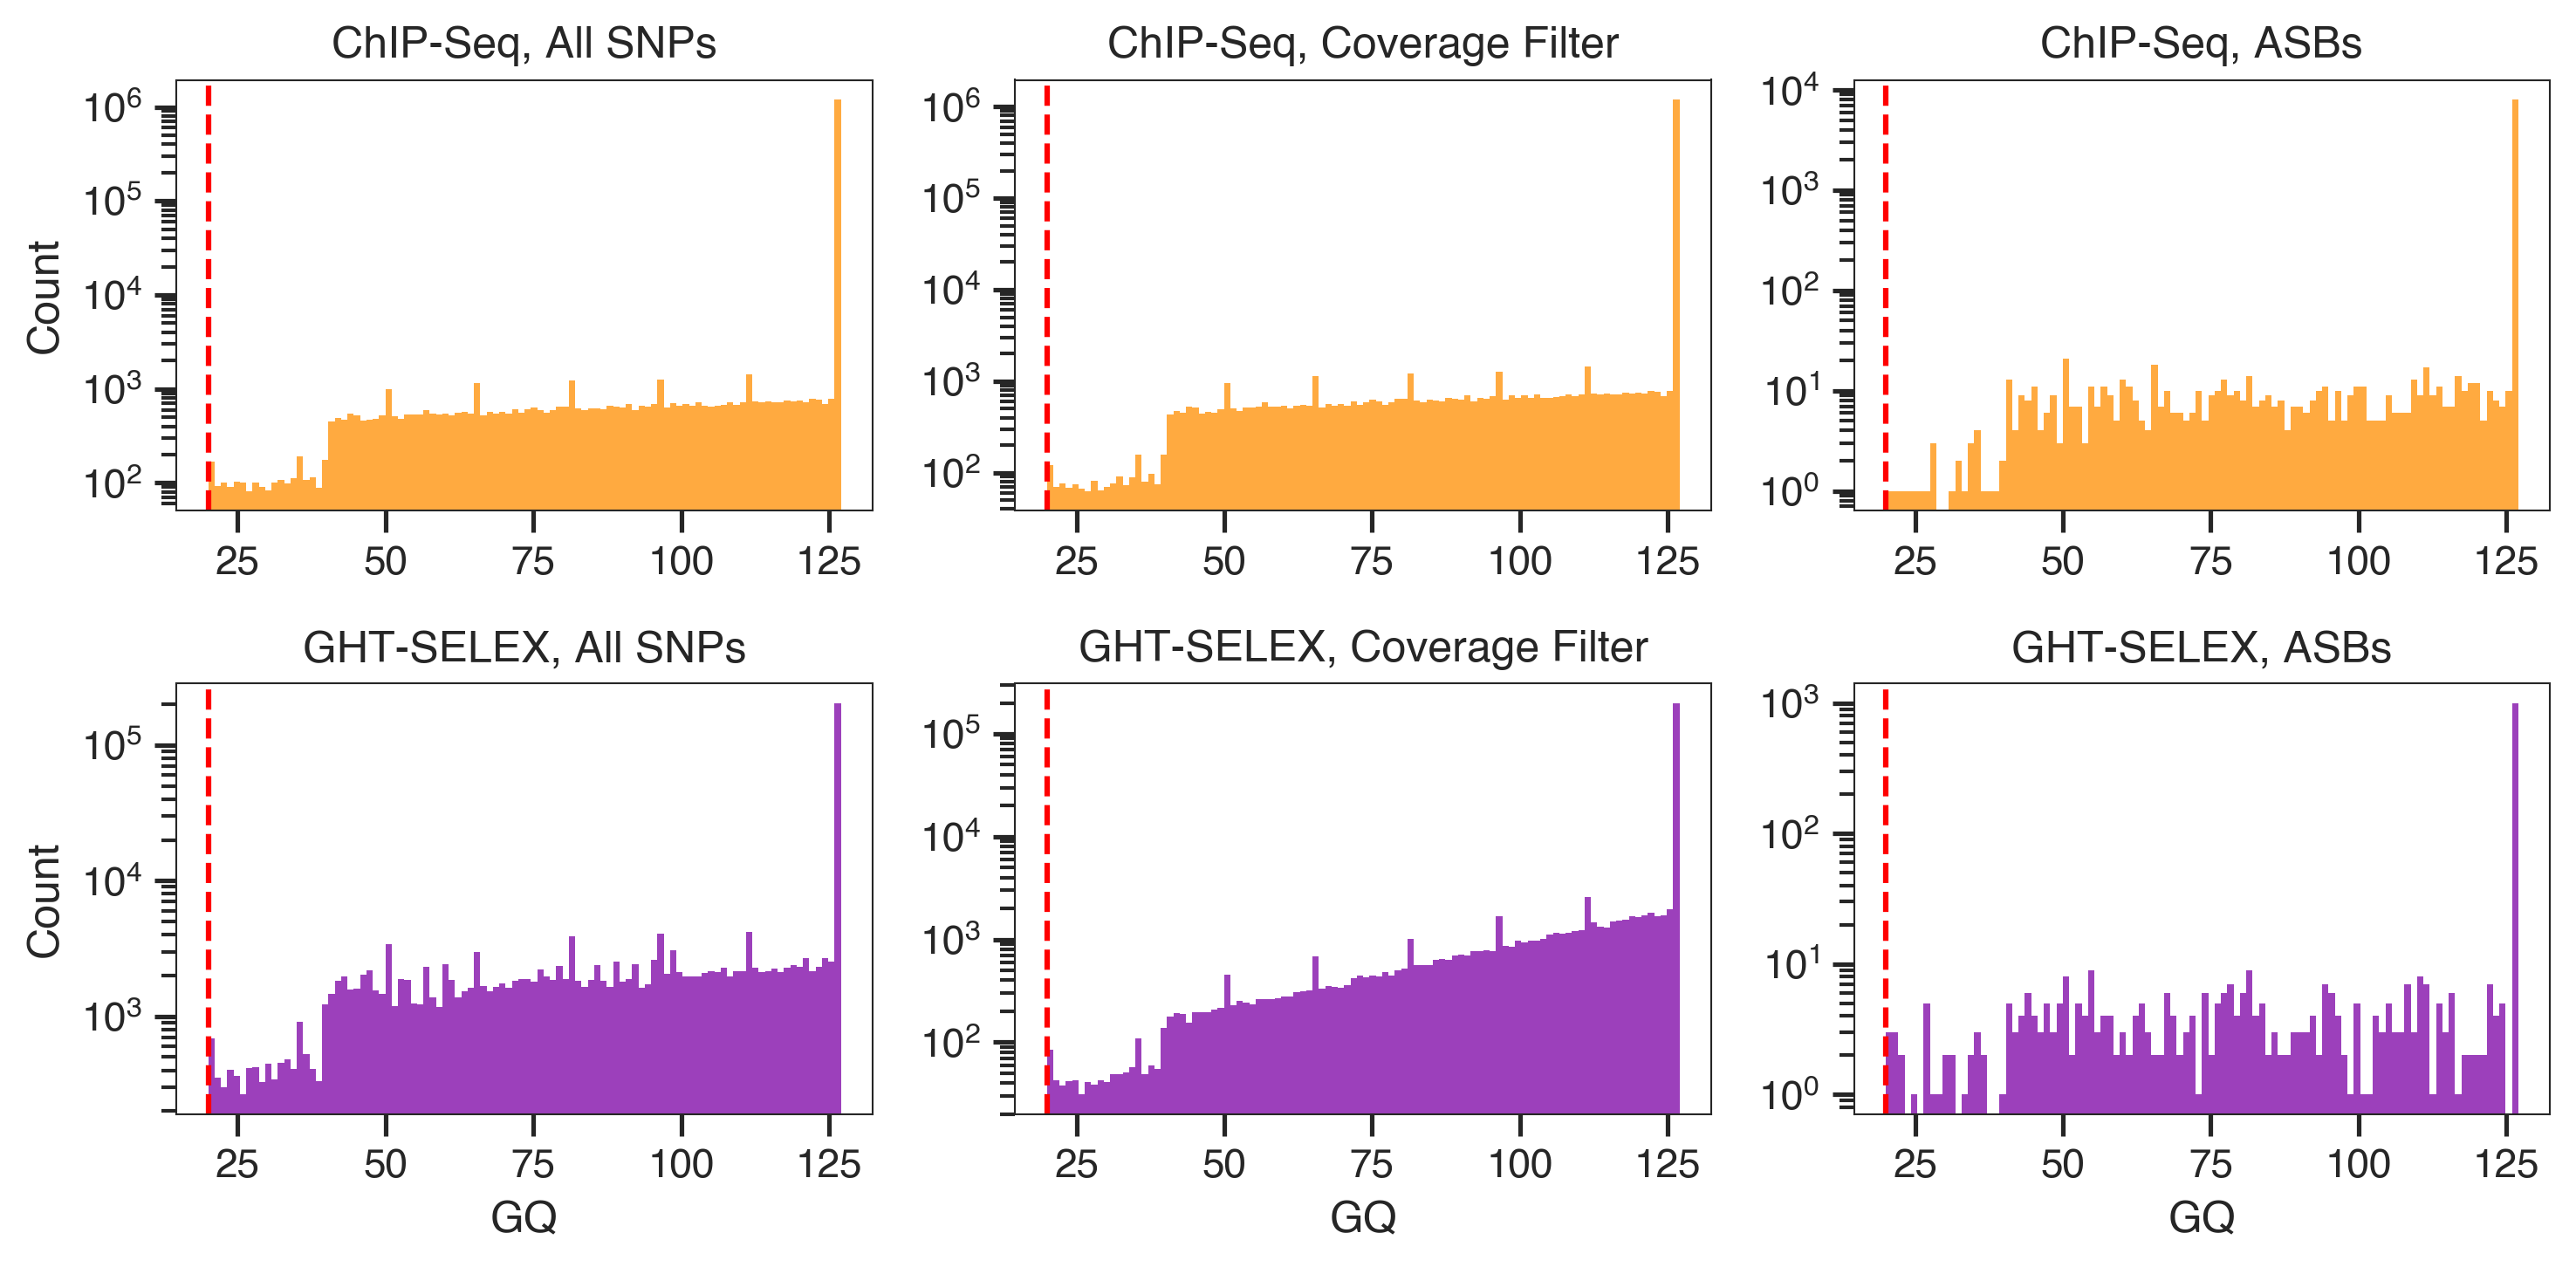

In [59]:
fig, ax = plt.subplots(2, 3, figsize=(10, 5), dpi=300)
ax_width = 0.5

j, i = 0, 0
sns.histplot(data.query('exp == "chipseq"'), x='GQ', bins=100, ax=ax[i][j], linewidth=0, color=CHIPSEQ_COLOR)
ax[i][j].axvline(x=20, color='red', linestyle='--')
ax[i][j].set_title('ChIP-Seq, All SNPs')
ax[i][j].set_yscale('log')
ax[i][j].set_xlabel('')
for spine in ax[i][j].spines.values():
    spine.set_linewidth(ax_width)

j, i = 1, 0
sns.histplot(data.query('(exp == "chipseq") & coverage'), x='GQ', bins=100, ax=ax[i][j], linewidth=0, color=CHIPSEQ_COLOR)
ax[i][j].axvline(x=20, color='red', linestyle='--')
ax[i][j].set_title('ChIP-Seq, Coverage Filter')
ax[i][j].set_yscale('log')
ax[i][j].set_xlabel('')
ax[i][j].set_ylabel('')
for spine in ax[i][j].spines.values():
    spine.set_linewidth(ax_width)

j, i = 2, 0
sns.histplot(data.query('(exp == "chipseq") & asb'), x='GQ', bins=100, ax=ax[i][j], linewidth=0, color=CHIPSEQ_COLOR)
ax[i][j].axvline(x=20, color='red', linestyle='--')
ax[i][j].set_title('ChIP-Seq, ASBs')
ax[i][j].set_yscale('log')
ax[i][j].set_xlabel('')
ax[i][j].set_ylabel('')
for spine in ax[i][j].spines.values():
    spine.set_linewidth(ax_width)


j, i = 0, 1
sns.histplot(data.query('exp == "ght-selex"'), x='GQ', bins=100, ax=ax[i][j], linewidth=0, color=SELEX_COLOR)
ax[i][j].axvline(x=20, color='red', linestyle='--')
ax[i][j].set_title('GHT-SELEX, All SNPs')
ax[i][j].set_yscale('log')
for spine in ax[i][j].spines.values():
    spine.set_linewidth(ax_width)

j, i = 1, 1
sns.histplot(data.query('(exp == "ght-selex") & coverage'), x='GQ', bins=100, ax=ax[i][j], linewidth=0, color=SELEX_COLOR)
ax[i][j].axvline(x=20, color='red', linestyle='--')
ax[i][j].set_title('GHT-SELEX, Coverage Filter')
ax[i][j].set_yscale('log')
ax[i][j].set_ylabel('')
for spine in ax[i][j].spines.values():
    spine.set_linewidth(ax_width)

j, i = 2, 1
sns.histplot(data.query('(exp == "ght-selex") & asb'), x='GQ', bins=100, ax=ax[i][j], linewidth=0, color=SELEX_COLOR)
ax[i][j].axvline(x=20, color='red', linestyle='--')
ax[i][j].set_title('GHT-SELEX, ASBs')
ax[i][j].set_yscale('log')
ax[i][j].set_ylabel('')
for spine in ax[i][j].spines.values():
    spine.set_linewidth(ax_width)
fig.tight_layout()
plt.savefig('figures/GQ_distribution.png', bbox_inches='tight')
plt.savefig('figures/GQ_distribution.pdf', bbox_inches='tight')

In [49]:

data

,GT,PL,DP,AD,GQ,id,ref,alt,exp,ref_cnt,alt_cnt,coverage,asb
0,0/1,"255,0,189",521,"249,272",127,rs546169444,A,T,chipseq,249,272,True,False
1,0/1,"60,0,193",160,"120,40",58,rs6682385,A,G,chipseq,120,40,True,False
2,0/1,"54,0,255",146,"109,37",51,rs3982632,T,G,chipseq,109,37,True,False
3,0/1,"255,0,162",656,"194,462",127,rs3844233,A,T,chipseq,194,462,True,False
4,0/1,"117,0,255",544,"382,162",114,rs28619159,T,C,chipseq,382,162,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1636917,0/1,"119,0,58",11,"4,7",58,rs6009942,C,T,ght-selex,4,7,False,False
1636918,0/1,"119,0,58",11,"4,7",58,rs6010035,G,A,ght-selex,4,7,False,False
1636919,0/1,"255,0,76",1469,"352,1117",73,rs9616807,G,A,ght-selex,352,1117,True,False
1636920,0/1,"74,0,35",14,"5,9",34,rs9616904,C,T,ght-selex,5,9,True,False


In [50]:
chs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3177503 entries, 0 to 3177502
Data columns (total 12 columns):
 #   Column   Dtype  
---  ------   -----  
 0   #CHROM   object 
 1   POS      int64  
 2   ID       object 
 3   REF      object 
 4   ALT      object 
 5   QUAL     float64
 6   FILTER   object 
 7   INFO     object 
 8   FORMAT   object 
 9   chipseq  object 
 10  data     object 
 11  exp      object 
dtypes: float64(1), int64(1), object(10)
memory usage: 290.9+ MB


In [51]:
chs

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,chipseq,data,exp
0,chr1,12719,.,G,C,59.0000,PASS,DP=25;NS=1;AN=2;AF=0.5;MAF=0.5;AC=1;AC_Het=1;A...,GT:PL:DP:AD:GQ,"0/1:92,0,79:25:10,15:80","0/1:92,0,79:25:10,15:80",chipseq
1,chr1,12807,.,C,T,47.3647,PASS,DP=75;NS=1;AN=2;AF=0.5;MAF=0.5;AC=1;AC_Het=1;A...,GT:PL:DP:AD:GQ,"0/1:80,0,95:75:40,35:82","0/1:80,0,95:75:40,35:82",chipseq
2,chr1,13868,.,A,G,14.1734,PASS,DP=265;NS=1;AN=2;AF=0.5;MAF=0.5;AC=1;AC_Het=1;...,GT:PL:DP:AD:GQ,"0/1:48,0,210:224:173,51:45","0/1:48,0,210:224:173,51:45",chipseq
3,chr1,14464,rs546169444,A,T,222.0000,PASS,DP=613;NS=1;AN=2;AF=0.5;MAF=0.5;AC=1;AC_Het=1;...,GT:PL:DP:AD:GQ,"0/1:255,0,189:521:249,272:127","0/1:255,0,189:521:249,272:127",chipseq
4,chr1,14930,rs6682385,A,G,26.1128,PASS,DP=166;NS=1;AN=2;AF=0.5;MAF=0.5;AC=1;AC_Het=1;...,GT:PL:DP:AD:GQ,"0/1:60,0,193:160:120,40:58","0/1:60,0,193:160:120,40:58",chipseq
...,...,...,...,...,...,...,...,...,...,...,...,...
3177498,chr22,50807830,.,A,C,145.0000,PASS,DP=854;NS=1;AN=2;AF=0.5;MAF=0.5;AC=1;AC_Het=1;...,GT:PL:DP:AD:GQ,"0/1:179,0,255:762:552,210:127","0/1:179,0,255:762:552,210:127",chipseq
3177499,chr22,50807871,.,T,G,225.0000,PASS,DP=302;NS=1;AN=2;AF=1;MAF=0;AC=2;AC_Het=0;AC_H...,GT:PL:DP:AD:GQ,"1/1:255,255,0:264:0,264:127","1/1:255,255,0:264:0,264:127",chipseq
3177500,chr22,50807889,.,C,G,228.0000,PASS,DP=130;NS=1;AN=2;AF=1;MAF=0;AC=2;AC_Het=0;AC_H...,GT:PL:DP:AD:GQ,"1/1:255,238,0:114:4,110:127","1/1:255,238,0:114:4,110:127",chipseq
3177501,chr22,50808115,.,T,C,10.3595,PASS,DP=326;NS=1;AN=2;AF=0.5;MAF=0.5;AC=1;AC_Het=1;...,GT:PL:DP:AD:GQ,"0/1:44,0,235:281:211,69:41","0/1:44,0,235:281:211,69:41",chipseq


In [52]:
def get_sample(x):
    if x is None:
        return None
    return x.split('/')[1].split('.')[1]

def unique(row):
    return len(set(filter(lambda x: x is not None, row)))

asbs['samples'] = asbs['scorefiles'].str.split(',', expand=True).map(get_sample).apply(unique, axis=1)

In [53]:
asbs

,#chr,start,end,mean_bad,id,max_cover,ref,alt,n_reps,bads,...,alt_comb_pval,ref_fdr_comb_pval,alt_fdr_comb_pval,pref_allele,comb_es,comb_pval,fdr_comb_pval,tf,exp,samples
0,chr16,46389973,46389974,3.0,rs4404093,24,C,G,1,3,...,0.319598,1.000000,0.697304,alt,0.293780,0.319598,0.697304,ZNF551,ght-selex,1
1,chr1,5881924,5881925,2.0,rs72630606,26,G,A,1,2,...,0.786422,0.925869,0.943706,ref,0.367775,0.212270,0.925869,ZNF551,ght-selex,1
2,chr1,182606535,182606536,2.0,rs3754289,43,G,A,1,2,...,0.995184,0.214646,1.000000,ref,1.653260,0.017887,0.214646,ZNF551,ght-selex,1
3,chr1,187798016,187798017,2.0,rs2215695,73,G,A,1,2,...,0.476428,0.925869,0.728910,ref,0.793484,0.206729,0.925869,ZNF551,ght-selex,1
4,chr2,30948543,30948544,2.0,rs889897,154,C,T,3,"2,2,2",...,0.387765,1.000000,0.712029,alt,0.257973,0.387765,0.712029,ZNF551,ght-selex,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5643,chr17,20534998,20534999,2.0,rs4519383,21,A,G,1,2,...,0.448736,0.718154,0.743856,ref,-0.061094,0.381813,0.718154,PAX7,chipseq,1
5644,chr19,36240521,36240522,4.0,rs4806295,30,A,G,1,4,...,0.590862,0.640928,0.836597,ref,0.737790,0.203354,0.640928,PAX7,chipseq,1
5645,chr21,37567800,37567801,3.0,rs2248669,20,G,C,1,3,...,1.000000,0.565848,1.000000,ref,0.774614,0.136060,0.565848,PAX7,chipseq,1
5646,chr21,39167833,39167834,3.0,rs429955,23,G,A,1,3,...,0.600799,0.666692,0.840221,ref,0.390861,0.259005,0.666692,PAX7,chipseq,1


In [54]:
signif_asb

,id,exp,asb
9,rs483664,ght-selex,True
12,rs7455815,ght-selex,True
17,rs1372850,ght-selex,True
18,rs1372849,ght-selex,True
6,rs7590434,ght-selex,True
...,...,...,...
5481,rs62134790,chipseq,True
5504,rs6041221,chipseq,True
5512,rs62209634,chipseq,True
5540,rs6022656,chipseq,True


In [55]:
limit = 5

support = asbs.groupby(['id', 'exp'])['samples'].sum().reset_index().merge(signif_asb, on=['id', 'exp'], how='left')
support['asb'] = np.where((~support['asb'].isna()), True, False)
support['samples'] = np.where(support['samples'] > limit, f'> {limit}', support['samples'].astype(str))
support
support = support.merge(support.groupby('asb')['id'].count().reset_index(), on='asb', suffixes=('', '_y'))
order = list(map(lambda x: str(x), range(1, limit+1))) + [f'> {limit}']

In [56]:
order

['1', '2', '3', '4', '5', '> 5']

In [57]:

processed = support.groupby(['asb', 'samples'])['id'].count().reset_index().merge(support.groupby('asb')['id'].count().reset_index(), on='asb')
processed['fraction'] = processed['id_x']/processed['id_y']
processed['asb'] = np.where(processed['asb'], 'ASB', 'non-ASB')

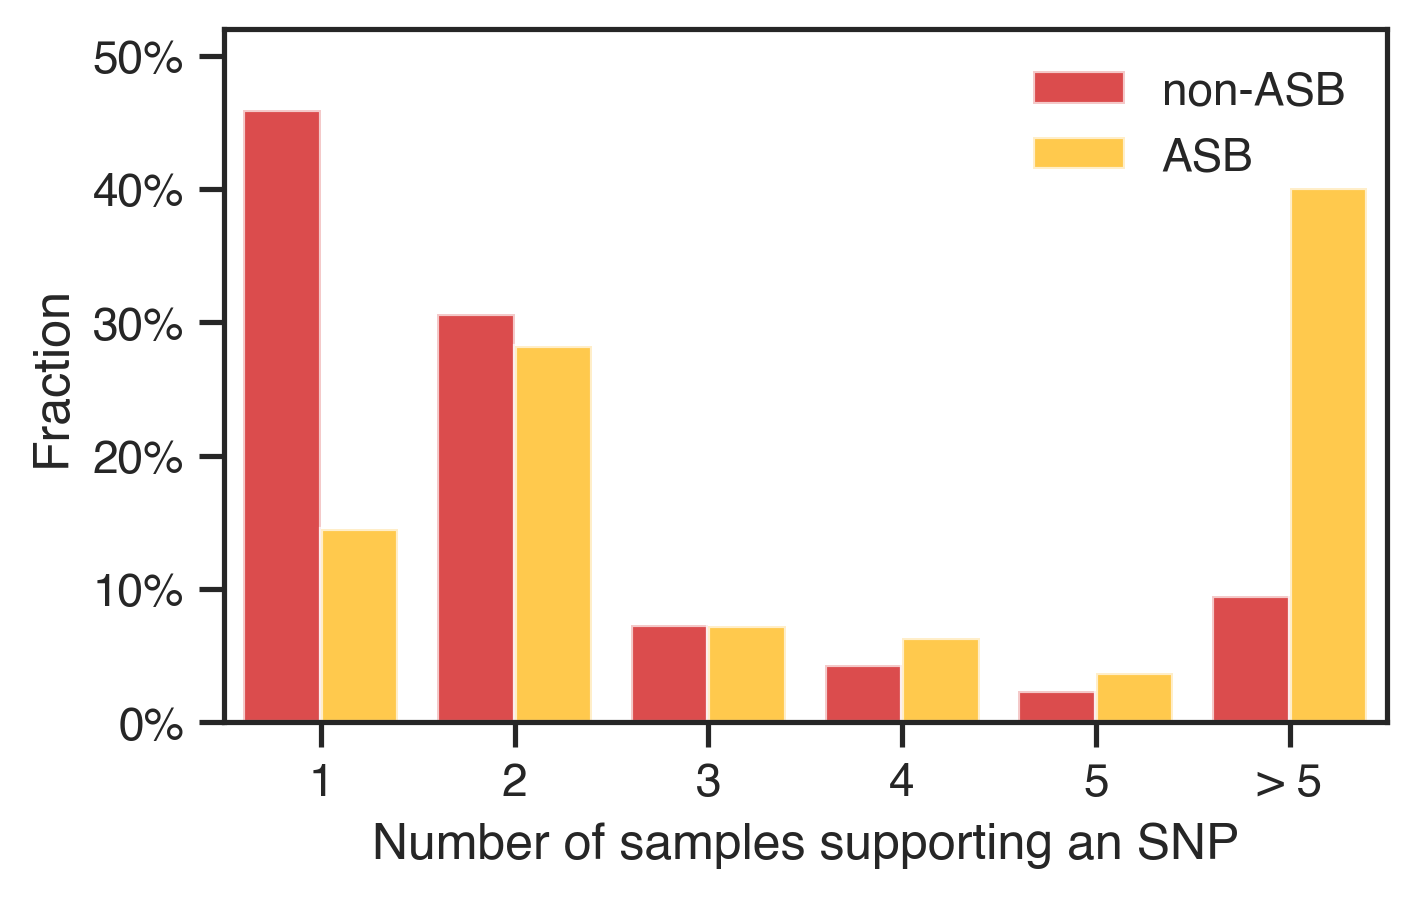

In [60]:

fig, ax = plt.subplots(figsize=(5, 3), dpi=300)
sns.barplot(
    processed, 
    x='samples', 
    y='fraction', 
    hue='asb', 
    order=order, 
    palette=[palette[0], palette[1]],
    saturation=1, 
    alpha=0.7,
    ax=ax
)
ax.set_xlabel('Number of samples supporting an SNP')
ax.set_ylabel('Fraction')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylim((0, 0.52))
plt.legend(frameon=False, loc='upper right')
plt.savefig('figures/support.png', bbox_inches='tight')
plt.savefig('figures/support.pdf', bbox_inches='tight')